# Tech Challenge — Fase 2
## Classificando a Qualidade de Vinhos com Machine Learning

**Curso:** POSTECH — Data Analytics (DTAT)
**Case:** Wine Quality Dataset (Kaggle, `yasserh/wine-quality-dataset`, arquivo `WineQT.csv`)
**Objetivo:** desenvolver e comparar modelos de classificação binária capazes de prever se um vinho é de **Alta Qualidade** (nota ≥ 7) a partir de suas características físico-químicas.

---

### Sumário

1. [Compreensão do Problema](#1)
2. [Carregamento e Auditoria dos Dados](#2)
3. [Análise Exploratória de Dados (EDA)](#3)
4. [Pré-processamento](#4)
5. [Desenvolvimento dos Modelos](#5)
6. [Avaliação dos Modelos](#6)
7. [Interpretação dos Resultados](#7)
8. [Conclusões e Recomendações](#8)

<a id="1"></a>
## 1. Compreensão do Problema

### 1.1 Contexto de negócio

A avaliação da qualidade de vinhos é tradicionalmente realizada por painéis de especialistas por meio de análise sensorial — um processo **subjetivo e caro**, que além de demorado depende da disponibilidade e da experiência dos avaliadores. Como as propriedades físico-químicas do vinho (acidez, teor alcoólico, dióxido de enxofre etc.) são medidas rotineiramente no laboratório da vinícola durante a produção, um modelo preditivo treinado sobre esses dados permite:

- **antecipar** a classificação de qualidade antes do painel sensorial;
- **priorizar** quais lotes devem ser degustados pelos especialistas;
- **ajustar o processo produtivo** (ex.: controle de acidez volátil) enquanto ainda há tempo de intervenção;
- **padronizar** a qualidade entre safras e lotes.

### 1.2 Definição da variável alvo

A base atribui a cada amostra uma nota de qualidade (`quality`) de 3 a 8, dada por especialistas. Conforme solicitado no desafio, o problema foi convertido em **classificação binária**:

| Classe | Critério | Interpretação |
|---|---|---|
| **1 — Alta Qualidade** | `quality` ≥ 7 | vinho premium, apto a posicionamento superior |
| **0 — Baixa/Média Qualidade** | `quality` < 7 | vinho padrão |

### 1.3 Justificativa técnica da binarização

1. **Alinhamento com a decisão de negócio**: a pergunta prática da vinícola é "este lote é premium ou não?" — uma decisão binária, e não a previsão exata da nota.
2. **Escassez nas classes extremas**: as notas 3, 4 e 8 possuem pouquíssimas amostras, o que inviabiliza um classificador multiclasse confiável (classes com < 40 observações).
3. **Robustez ao ruído do avaliador**: a diferença entre notas vizinhas (5 vs. 6) é subjetiva; o corte em 7 separa grupos com perfis físico-químicos de fato distintos, como a EDA confirmará.

O corte em 7 gera, entretanto, um **forte desbalanceamento de classes** (≈ 13% de positivos), que será tratado explicitamente na modelagem — na escolha das métricas, na estratificação e na ponderação de classes.

<a id="2"></a>
## 2. Carregamento e Auditoria dos Dados

In [1]:
# Bibliotecas
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest, mannwhitneyu, spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score,
                             confusion_matrix, f1_score,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Configuração visual e reprodutibilidade
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
RESULTS = "../results" 

In [2]:
df = pd.read_csv("../data/WineQT.csv")
print(f"Dimensões: {df.shape[0]} amostras x {df.shape[1]} colunas")
df.head()

Dimensões: 1143 amostras x 13 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


### 2.1 Dicionário de variáveis

| Variável | Descrição | Papel enológico |
|---|---|---|
| `fixed acidity` | Acidez fixa (g/L de ácido tartárico) | estrutura e frescor do vinho |
| `volatile acidity` | Acidez volátil (g/L de ácido acético) | em excesso, gera aroma de vinagre — defeito |
| `citric acid` | Ácido cítrico (g/L) | acrescenta frescor e sabor |
| `residual sugar` | Açúcar residual (g/L) | doçura remanescente após fermentação |
| `chlorides` | Cloretos (g/L) | salinidade; valores altos indicam defeito |
| `free sulfur dioxide` | SO₂ livre (mg/L) | proteção microbiológica ativa |
| `total sulfur dioxide` | SO₂ total (mg/L) | em excesso, afeta aroma e saúde |
| `density` | Densidade (g/cm³) | proxy de álcool e açúcar |
| `pH` | pH | equilíbrio ácido-base |
| `sulphates` | Sulfatos (g/L) | antimicrobiano; contribui para SO₂ |
| `alcohol` | Teor alcoólico (% vol.) | corpo e percepção de qualidade |
| `quality` | Nota do especialista (3–8) | **variável alvo original** |
| `Id` | Identificador da amostra | sem valor preditivo — será removida |

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
# Auditoria de qualidade dos dados
print(f"Valores faltantes: {df.isnull().sum().sum()}")
print(f"Linhas duplicadas (ignorando Id): {df.drop(columns=['Id']).duplicated().sum()}")
df.describe().T.round(3)

Valores faltantes: 0
Linhas duplicadas (ignorando Id): 125


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311,1.748,4.600,7.100,7.900,9.100,15.900
volatile acidity,1143.0,0.531,0.180,0.120,0.392,0.520,0.640,1.580
citric acid,1143.0,0.268,0.197,0.000,0.090,0.250,0.420,1.000
residual sugar,1143.0,2.532,1.356,0.900,1.900,2.200,2.600,15.500
chlorides,1143.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1143.0,15.615,10.250,1.000,7.000,13.000,21.000,68.000
total sulfur dioxide,1143.0,45.915,32.782,6.000,21.000,37.000,61.000,289.000
density,1143.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1143.0,3.311,0.157,2.740,3.205,3.310,3.400,4.010
sulphates,1143.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


### 2.2 Diagnóstico da auditoria

- **Valores faltantes: zero.** Nenhuma técnica de imputação é necessária; a decisão está documentada na etapa de pré-processamento.
- **Duplicatas: 125 registros** com físico-química idêntica (o `Id` difere, mas o conteúdo é o mesmo). Duplicatas serão **removidas** por dois motivos: (i) inflam artificialmente o peso de certas amostras no treino; (ii) se caíssem simultaneamente em treino e teste, causariam **vazamento de dados** (data leakage), superestimando as métricas.
- **Tipos corretos**: todas as variáveis são numéricas contínuas; não há necessidade de encoding de variáveis categóricas.
- **Faixas plausíveis**: os intervalos observados (pH 2,74–4,01; álcool 8,4–14,9%) são fisicamente consistentes com vinho tinto, sem valores impossíveis (negativos ou nulos onde não deveriam existir).

In [5]:
# Remoção do Id, das duplicatas e criação da variável alvo binária
df = df.drop(columns=["Id"]).drop_duplicates().reset_index(drop=True)
df["alta_qualidade"] = (df["quality"] >= 7).astype(int)

FEATURES = [c for c in df.columns if c not in ("quality", "alta_qualidade")]
LABELS_PT = {
    "fixed acidity": "Acidez fixa", "volatile acidity": "Acidez volátil",
    "citric acid": "Ácido cítrico", "residual sugar": "Açúcar residual",
    "chlorides": "Cloretos", "free sulfur dioxide": "SO₂ livre",
    "total sulfur dioxide": "SO₂ total", "density": "Densidade",
    "pH": "pH", "sulphates": "Sulfatos", "alcohol": "Teor alcoólico",
    "razao_so2": "Razão SO₂ (livre/total)",
    "interacao_alcool_sulfatos": "Interação álcool × sulfatos",
}

n_alta = df["alta_qualidade"].sum()
print(f"Base final: {len(df)} amostras")
print(f"Alta qualidade: {n_alta} ({n_alta/len(df)*100:.2f}%)")
print(f"Baixa/Média:    {len(df)-n_alta} ({(len(df)-n_alta)/len(df)*100:.2f}%)")

Base final: 1018 amostras
Alta qualidade: 137 (13.46%)
Baixa/Média:    881 (86.54%)


<a id="3"></a>
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Distribuição da variável alvo e balanceamento das classes

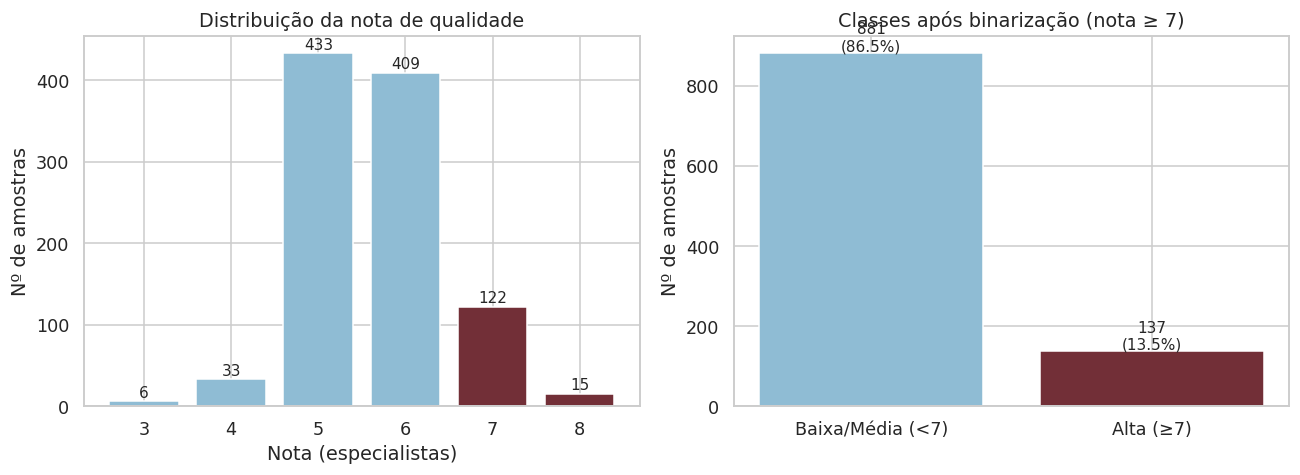

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
counts = df["quality"].value_counts().sort_index()
colors = ["#722F37" if q >= 7 else "#8FBCD4" for q in counts.index]
axes[0].bar(counts.index.astype(str), counts.values, color=colors)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontsize=10)
axes[0].set_title("Distribuição da nota de qualidade")
axes[0].set_xlabel("Nota (especialistas)")
axes[0].set_ylabel("Nº de amostras")

bin_counts = df["alta_qualidade"].value_counts()
axes[1].bar(["Baixa/Média (<7)", "Alta (≥7)"], [bin_counts[0], bin_counts[1]],
            color=["#8FBCD4", "#722F37"])
for i, v in enumerate([bin_counts[0], bin_counts[1]]):
    axes[1].text(i, v + 5, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
axes[1].set_title("Classes após binarização (nota ≥ 7)")
axes[1].set_ylabel("Nº de amostras")
plt.tight_layout()
plt.savefig(f"{RESULTS}/01_distribuicao_variavel_alvo.png", bbox_inches="tight")
plt.show()

**Interpretação.** A nota concentra-se em 5 e 6 (≈ 83% da base) — os especialistas raramente atribuem notas extremas. Após a binarização, apenas **13,5%** das amostras são de Alta Qualidade (137 de 1.018), configurando um problema **desbalanceado na proporção ≈ 6,4 : 1**. Três consequências diretas para a modelagem:

1. a **acurácia isolada é enganosa**: um modelo que sempre previsse "Baixa/Média" atingiria 86,5% de acurácia na base completa (86,8% no recorte de teste) sem identificar um único vinho premium;
2. **F1-score e ROC AUC** serão as métricas de referência;
3. o split treino/teste será **estratificado** e os modelos usarão **ponderação de classes** (`class_weight="balanced"` / `scale_pos_weight`).

### 3.2 Distribuição das variáveis físico-químicas

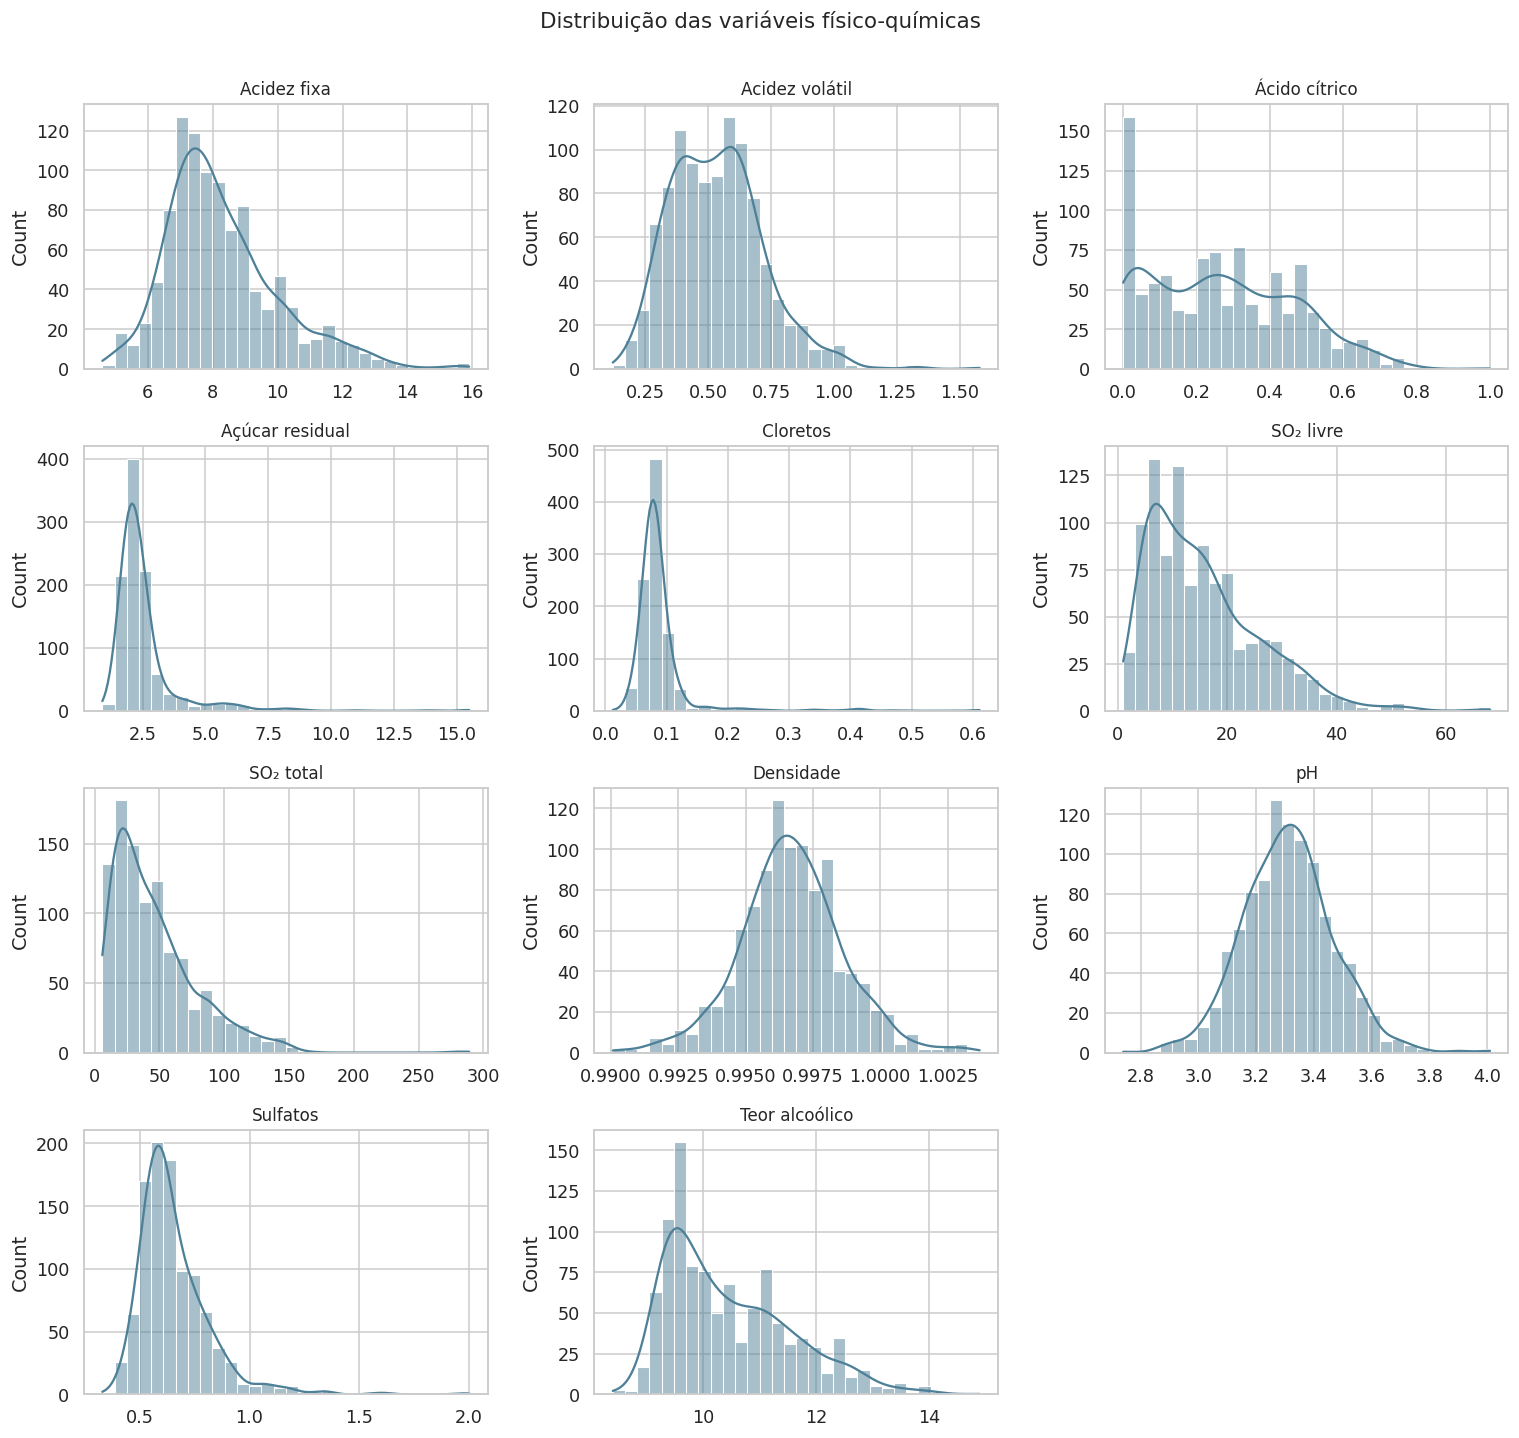

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(14, 13))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="#4E8098", bins=30)
    ax.set_title(LABELS_PT[col], fontsize=11)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Distribuição das variáveis físico-químicas", y=1.005, fontsize=14)
plt.tight_layout()
plt.savefig(f"{RESULTS}/02_histogramas.png", bbox_inches="tight")
plt.show()

In [8]:
# Assimetria (skewness) de cada variável
df[FEATURES].skew().sort_values(ascending=False).round(2).to_frame("Assimetria")

,Assimetria
chlorides,5.93
residual sugar,4.35
sulphates,2.42
total sulfur dioxide,1.68
free sulfur dioxide,1.17
fixed acidity,1.04
alcohol,0.85
volatile acidity,0.72
citric acid,0.37
pH,0.26


**Interpretação.** Três padrões distintos emergem:

- **Aproximadamente simétricas**: densidade e pH seguem distribuições próximas da normal (assimetria < 0,3), comportamento esperado de propriedades físico-químicas controladas no processo.
- **Assimetria positiva forte** (cauda longa à direita): cloretos, açúcar residual e sulfatos. A maioria dos vinhos concentra-se em valores baixos, com poucos casos extremos; são as candidatas naturais a conterem outliers.
- **Bimodalidade leve** no ácido cítrico, com um grupo expressivo em zero (vinhos sem adição de ácido cítrico). Trata-se de uma característica real do processo produtivo, e não de erro de medição.

Como a padronização será feita via `StandardScaler` **dentro de um Pipeline** e os modelos de árvore são insensíveis a escala e monotonicidade, **não aplicamos transformação logarítmica**: o custo em interpretabilidade não se justificaria.

### 3.3 Comparação das variáveis entre classes (boxplots)

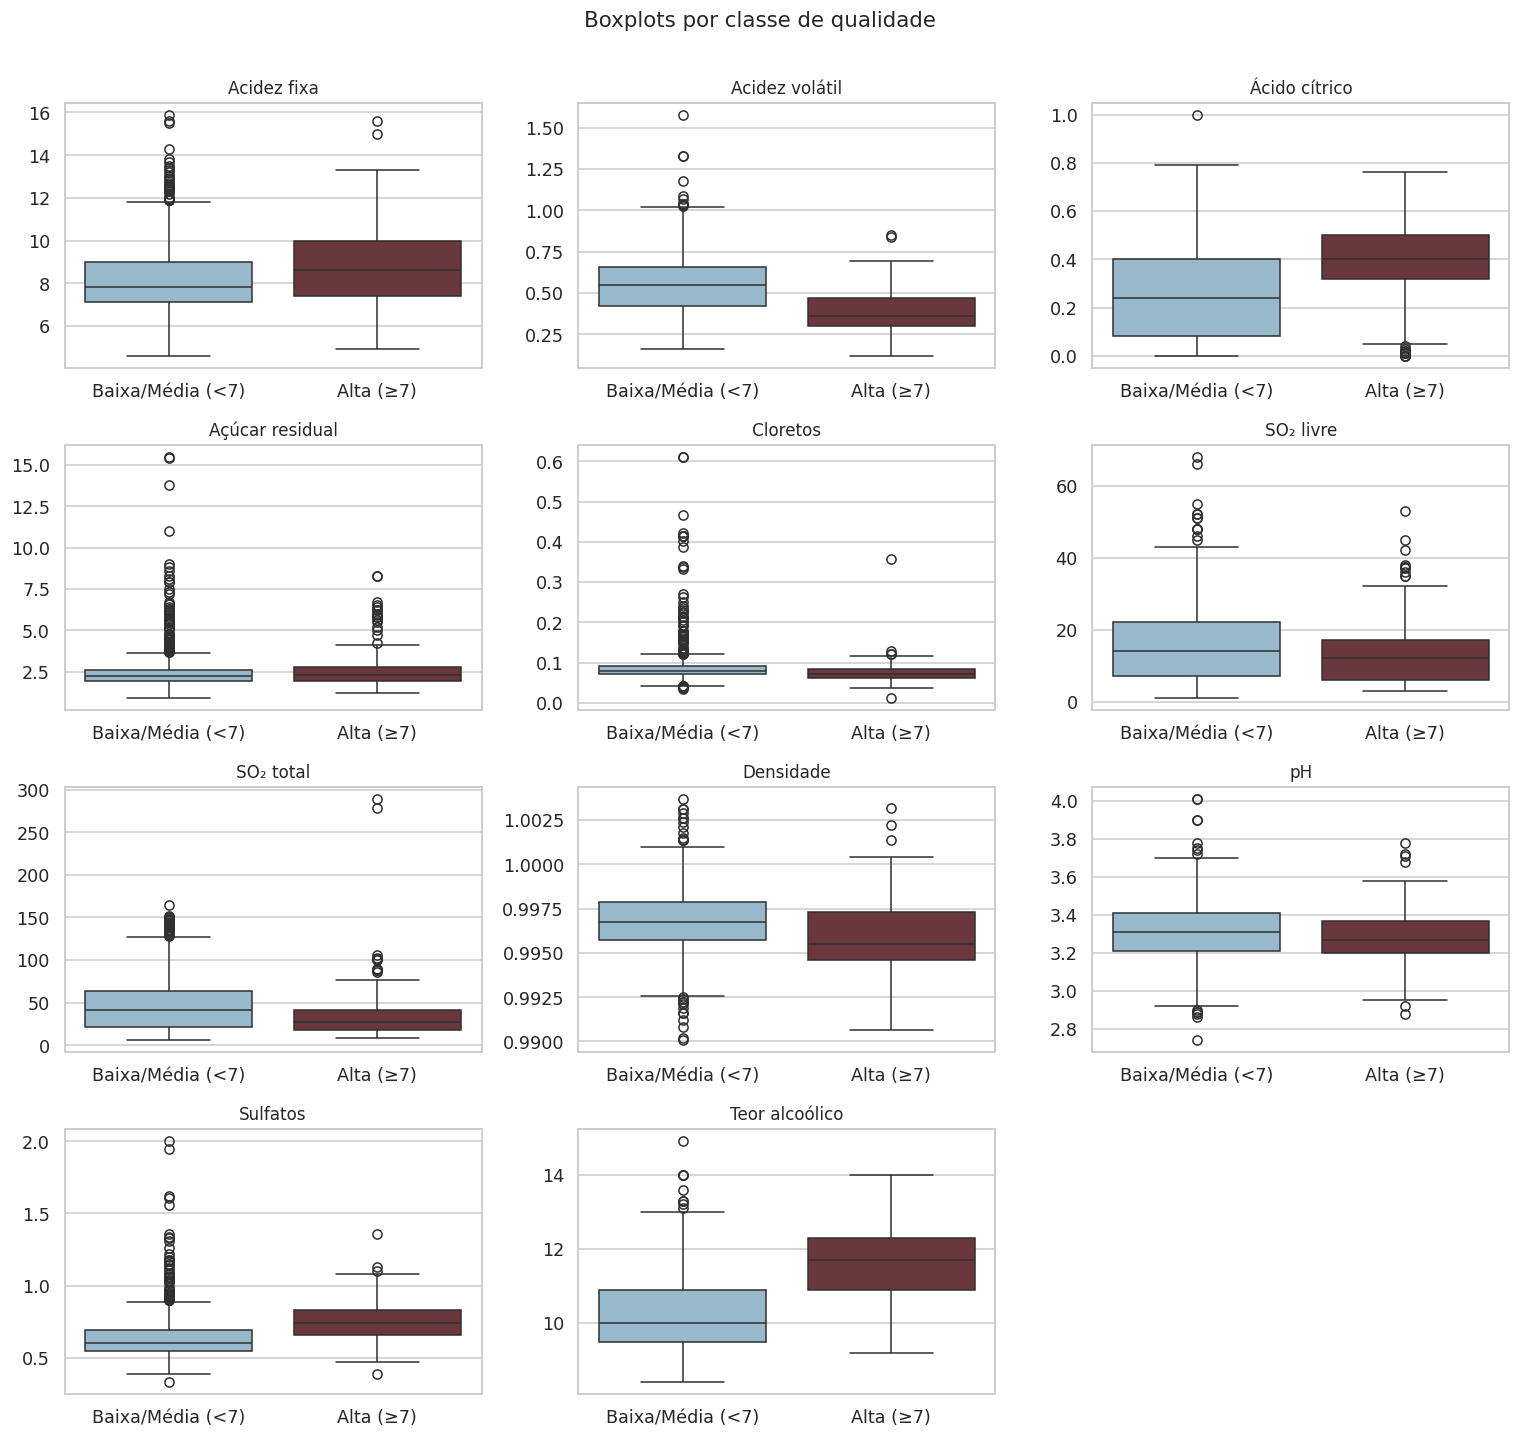

In [9]:
dfm = df.copy()
dfm["Classe"] = np.where(dfm["alta_qualidade"] == 1, "Alta (≥7)", "Baixa/Média (<7)")
fig, axes = plt.subplots(4, 3, figsize=(14, 13))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(data=dfm, x="Classe", y=col, hue="Classe", ax=ax,
                palette=["#8FBCD4", "#722F37"], legend=False)
    ax.set_title(LABELS_PT[col], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes.flat[-1].axis("off")
fig.suptitle("Boxplots por classe de qualidade", y=1.005, fontsize=14)
plt.tight_layout()
plt.savefig(f"{RESULTS}/03_boxplots_por_classe.png", bbox_inches="tight")
plt.show()

**Interpretação.** Os boxplots revelam quais variáveis de fato separam as classes:

- **Teor alcoólico**: a mediana dos vinhos de alta qualidade (11,7% vol.) supera com folga a dos demais (10,0% vol.); é o separador visual mais nítido.
- **Acidez volátil**: vinhos premium concentram-se em valores baixos (< 0,5 g/L); acidez volátil alta é literalmente um defeito sensorial (aroma avinagrado).
- **Sulfatos e ácido cítrico**: medianas visivelmente maiores na classe alta.
- **Açúcar residual e pH**: distribuições quase sobrepostas, com baixo poder discriminante individual.

Esses contrastes antecipam o ranking de importância que os modelos confirmarão na Seção 7.

### 3.4 Violin plots — as quatro variáveis mais discriminantes

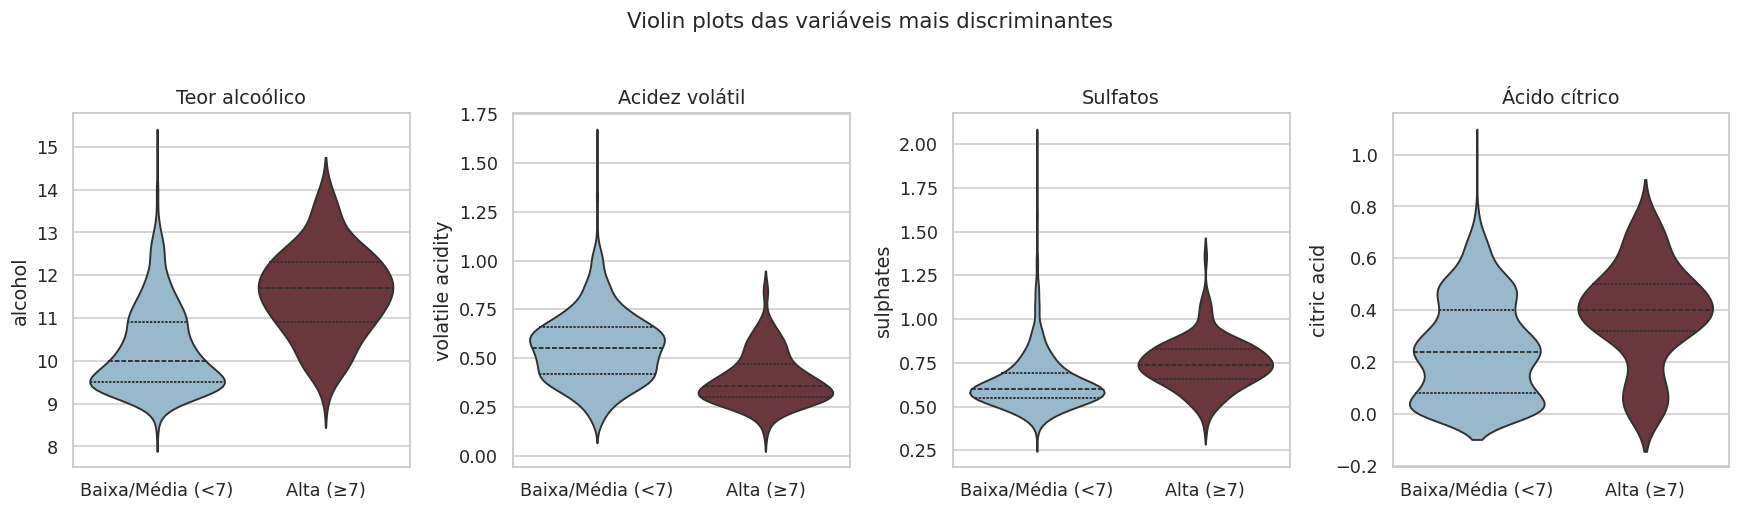

In [10]:
top4 = ["alcohol", "volatile acidity", "sulphates", "citric acid"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, col in zip(axes, top4):
    sns.violinplot(data=dfm, x="Classe", y=col, hue="Classe", ax=ax,
                   palette=["#8FBCD4", "#722F37"], legend=False, inner="quartile")
    ax.set_title(LABELS_PT[col])
    ax.set_xlabel("")
fig.suptitle("Violin plots das variáveis mais discriminantes", y=1.03, fontsize=14)
plt.tight_layout()
plt.savefig(f"{RESULTS}/04_violin_plots.png", bbox_inches="tight")
plt.show()

**Interpretação.** Os violin plots acrescentam a **forma** da distribuição aos quartis: no álcool, a densidade de vinhos premium desloca-se visivelmente para cima de 11%, enquanto a classe padrão concentra massa em torno de 9,5%; na acidez volátil, a classe alta é compacta e baixa, enquanto a classe padrão exibe cauda longa em direção a valores defeituosos. Isso confirma que a separação não é apenas de mediana, mas de **regime de distribuição**, condição favorável a modelos de árvore, que particionam o espaço por limiares.

### 3.5 Matriz de correlação

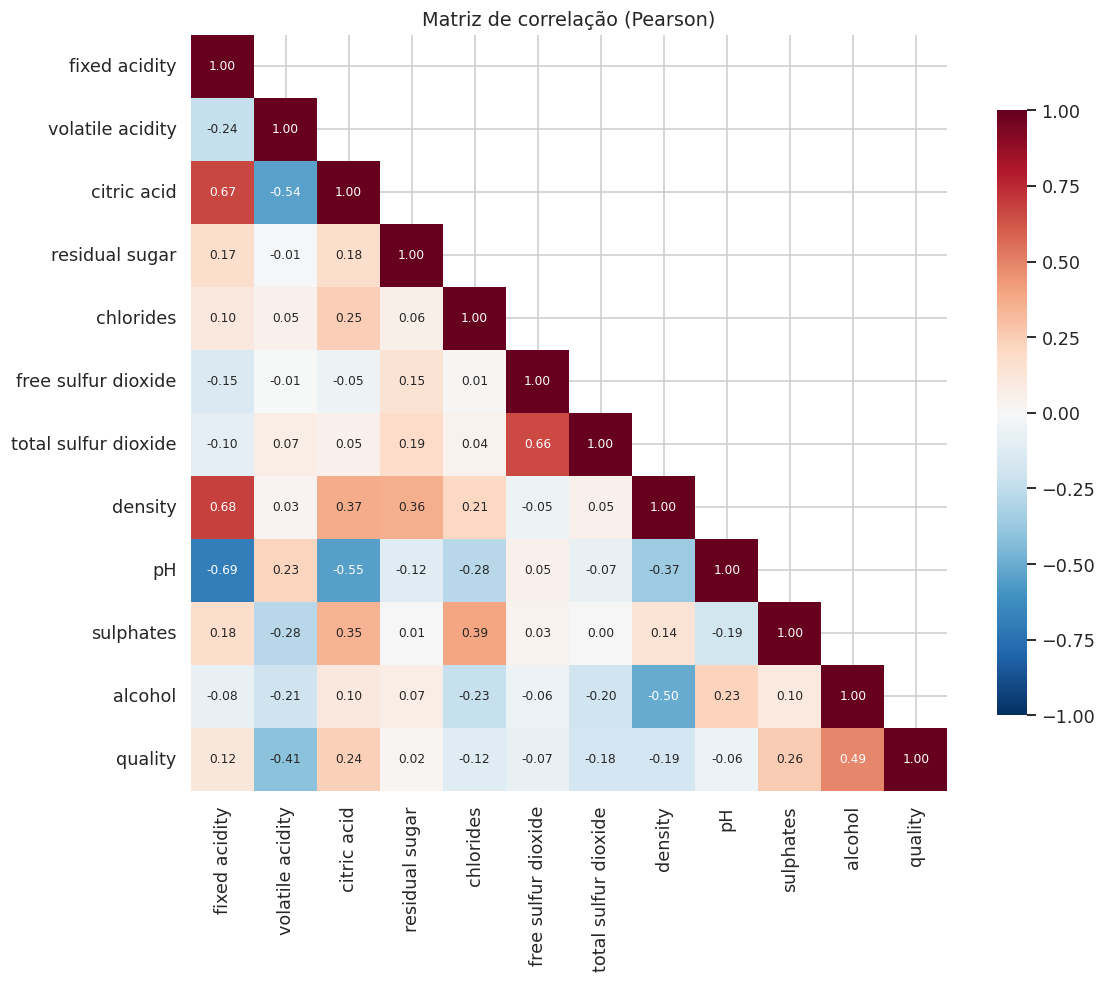

In [11]:
corr = df[FEATURES + ["quality"]].corr(method="pearson")
plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8})
plt.title("Matriz de correlação (Pearson)")
plt.tight_layout()
plt.savefig(f"{RESULTS}/05_heatmap_correlacao.png", bbox_inches="tight")
plt.show()

**Interpretação — correlações com a qualidade (justificativa par a par).**

| Par | r | Justificativa enológica |
|---|---|---|
| álcool × qualidade | **+0,49** | maior teor alcoólico deriva de uvas mais maduras e fermentação completa — corpo e complexidade percebidos pelos avaliadores |
| acidez volátil × qualidade | **−0,41** | ácido acético em excesso gera aroma de vinagre, defeito clássico penalizado na análise sensorial |
| sulfatos × qualidade | +0,26 | dosagem adequada protege o vinho da oxidação e de bactérias, preservando o perfil aromático |
| ácido cítrico × qualidade | +0,24 | contribui com frescor; correlaciona-se com boa gestão da acidez |
| densidade × qualidade | −0,19 | reflexo indireto: mais álcool → menor densidade (r álcool × densidade = −0,50) |
| SO₂ total × qualidade | −0,18 | excesso de conservante interfere no aroma |

**Correlações estruturais entre preditores** (multicolinearidade a monitorar):
- acidez fixa × ácido cítrico (+0,67), acidez fixa × densidade (+0,68) e acidez fixa × pH (−0,69): quimicamente esperadas — mais ácido implica menor pH e maior densidade;
- SO₂ livre × SO₂ total (+0,66): o SO₂ livre é parte do total.

Nenhum par ultrapassa |r| = 0,7, portanto **não removemos variáveis**. Para a Regressão Logística, a multicolinearidade moderada afeta a leitura dos coeficientes individuais (mas não a capacidade preditiva); os modelos de árvore são robustos a ela.

### 3.6 Correlação com a variável alvo binária

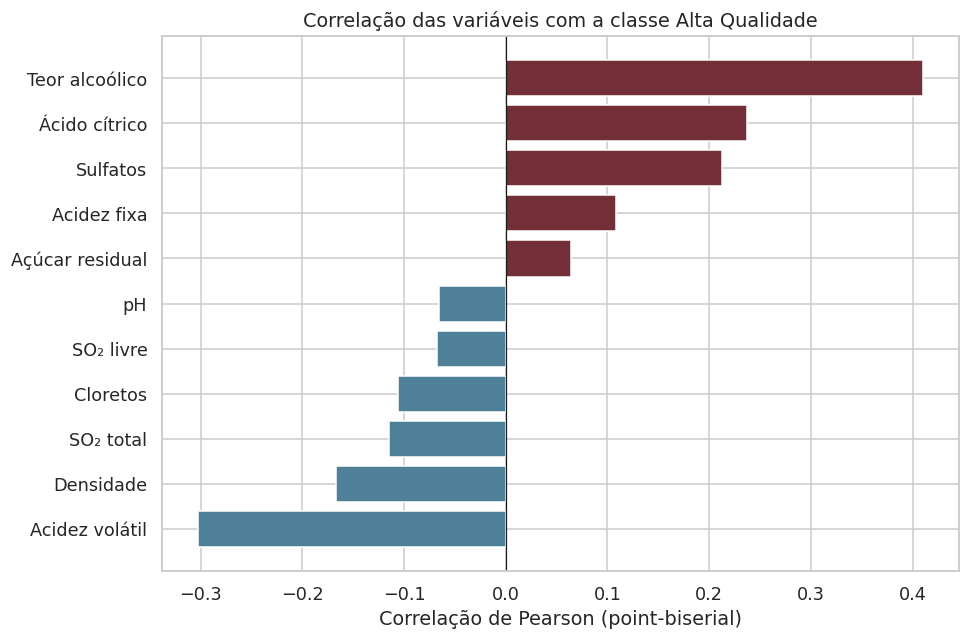

In [12]:
corr_bin = df[FEATURES].corrwith(df["alta_qualidade"]).sort_values()
plt.figure(figsize=(9, 6))
colors = ["#722F37" if v > 0 else "#4E8098" for v in corr_bin.values]
plt.barh([LABELS_PT[c] for c in corr_bin.index], corr_bin.values, color=colors)
plt.axvline(0, color="k", lw=0.8)
plt.title("Correlação das variáveis com a classe Alta Qualidade")
plt.xlabel("Correlação de Pearson (point-biserial)")
plt.tight_layout()
plt.savefig(f"{RESULTS}/06_correlacao_com_alvo.png", bbox_inches="tight")
plt.show()

**Interpretação.** Após a binarização a hierarquia se mantém: **álcool (+0,41)**, **acidez volátil (−0,30)**, **ácido cítrico (+0,24)** e **sulfatos (+0,21)** são os quatro sinais mais fortes. Nenhuma variável isolada é suficiente (|r| máximo de 0,41), o que justifica modelos multivariados capazes de capturar interações.

### 3.7 Significância estatística e correlação de Spearman

In [13]:
linhas = []
for col in FEATURES:
    _, p = mannwhitneyu(df.loc[df["alta_qualidade"] == 1, col],
                        df.loc[df["alta_qualidade"] == 0, col])
    rho, _ = spearmanr(df[col], df["alta_qualidade"])
    linhas.append({"Variável": LABELS_PT[col],
                   "p-valor (Mann-Whitney)": f"{p:.2e}",
                   "Spearman com o alvo": round(rho, 3)})

pd.DataFrame(linhas).sort_values("Spearman com o alvo",
                                 key=lambda s: s.abs(), ascending=False)

,Variável,p-valor (Mann-Whitney),Spearman com o alvo
10,Teor alcoólico,6.92e-35,0.386
1,Acidez volátil,2.03e-25,-0.327
9,Sulfatos,1.01e-20,0.293
2,Ácido cítrico,8.76e-14,0.234
4,Cloretos,6.82e-10,-0.193
7,Densidade,3.90e-08,-0.172
6,SO₂ total,7.91e-07,-0.155
0,Acidez fixa,3.49e-04,0.112
5,SO₂ livre,1.59e-02,-0.076
8,pH,2.24e-02,-0.072


**Interpretação.** As diferenças visuais dos boxplots foram submetidas a teste formal. Dez das onze variáveis apresentam diferença estatisticamente significativa entre as classes (p < 0,05 no teste de Mann-Whitney, apropriado para distribuições assimétricas como as vistas na Seção 3.2). A única exceção é o açúcar residual (p = 0,13), o que confirma seu baixo poder discriminante. O teor alcoólico carrega a evidência mais forte do conjunto (p da ordem de 10⁻³⁵).

Como robustez adicional, a correlação de Spearman (baseada em postos, insensível a outliers e a não linearidades monotônicas) preserva a hierarquia do Pearson: álcool (+0,39) e acidez volátil (−0,33) seguem dominantes. As conclusões da EDA não dependem, portanto, da escolha do coeficiente nem da presença de valores extremos.

### 3.8 Outliers e valores inconsistentes

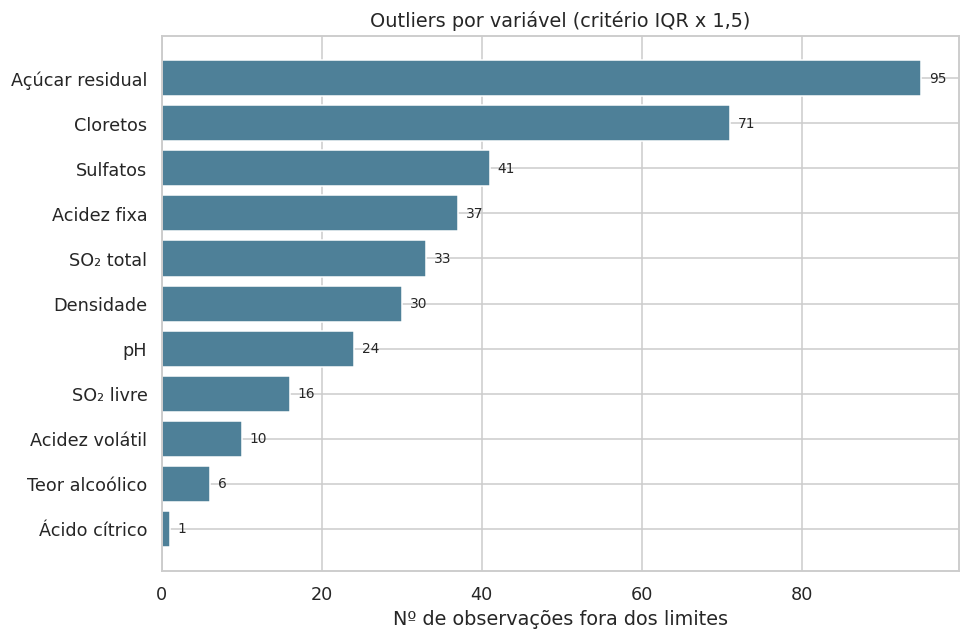

In [14]:
out_counts = {}
for col in FEATURES:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_counts[col] = int(((df[col] < lim_inf) | (df[col] > lim_sup)).sum())

oc = pd.Series(out_counts).sort_values()
plt.figure(figsize=(9, 6))
plt.barh([LABELS_PT[c] for c in oc.index], oc.values, color="#4E8098")
for i, v in enumerate(oc.values):
    plt.text(v + 1, i, str(v), va="center", fontsize=9)
plt.title("Outliers por variável (critério IQR x 1,5)")
plt.xlabel("Nº de observações fora dos limites")
plt.tight_layout()
plt.savefig(f"{RESULTS}/07_outliers_iqr.png", bbox_inches="tight")
plt.show()

**Interpretação e decisão.** O critério IQR sinaliza mais outliers em **açúcar residual (95)**, **cloretos (71)** e **sulfatos (41)** — exatamente as variáveis de cauda longa vistas nos histogramas. A inspeção dos valores extremos mostra que todos estão dentro de faixas **enologicamente possíveis** (ex.: açúcar residual de 15,5 g/L caracteriza um vinho levemente adocicado; SO₂ total de 289 mg/L é alto, mas factível).

**Decisão: manter os outliers.** Justificativa: (i) não há evidência de erro de medição — são vinhos raros, não dados errados; (ii) removê-los descartaria justamente exemplos informativos em uma base pequena e desbalanceada; (iii) os modelos escolhidos (árvores) são naturalmente robustos a valores extremos, e a Regressão Logística os recebe padronizados.

### 3.9 Insights executivos da EDA

1. **O álcool é o principal marcador de qualidade**: a mediana dos vinhos premium é de 11,7% vol., 1,7 ponto acima dos 10,0% vol. dos demais (1,3 ponto na média), com a evidência estatística mais forte do conjunto.
2. **Acidez volátil é o principal marcador de defeito**: mantê-la abaixo de cerca de 0,5 g/L é a alavanca de processo mais clara.
3. **Sulfatos e ácido cítrico atuam como coadjuvantes positivos**, ligados à proteção antioxidante e ao frescor.
4. **Apenas 13,5% dos vinhos alcançam o padrão premium**; o desbalanceamento é o desafio técnico central da modelagem.
5. **A base é limpa** (sem faltantes, sem inconsistências físicas), exigindo apenas remoção de duplicatas e padronização.

<a id="4"></a>
## 4. Pré-processamento

Resumo das decisões, todas justificadas tecnicamente:

| Etapa | Decisão | Justificativa |
|---|---|---|
| Dados faltantes | **Nenhuma imputação** | auditoria confirmou 0 valores faltantes |
| Duplicatas | **Removidas (125)** | evitar vazamento treino→teste e viés de peso |
| Outliers | **Mantidos** | valores enologicamente válidos; modelos robustos |
| Encoding | **Não necessário** | todas as features são numéricas contínuas |
| Padronização | **StandardScaler dentro de Pipeline** (apenas p/ Regressão Logística) | evita vazamento (média/desvio ajustados só no treino); árvores dispensam escala |
| Feature engineering | **Testada com validação cruzada** (abaixo) | features novas só entram se houver ganho mensurável |
| Split | **80/20 estratificado, `random_state=42`** | preserva a proporção de classes (13,5%) nos dois conjuntos e garante reprodutibilidade |

### 4.1 Feature engineering com validação empírica

Duas features derivadas com fundamento enológico:

- **`razao_so2`** = SO₂ livre / SO₂ total — fração do conservante efetivamente ativa (proteção real do vinho, independente da dose absoluta);
- **`interacao_alcool_sulfatos`** = álcool × sulfatos — captura a combinação "corpo + proteção antioxidante", os dois principais sinais positivos da EDA.

Critério de adoção: ganho de F1 em validação cruzada 5-fold no conjunto de treino. Nada entra "porque sim".

In [15]:
X = df[FEATURES].copy()
y = df["alta_qualidade"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Treino: {len(X_train)} amostras ({y_train.mean()*100:.2f}% alta qualidade)")
print(f"Teste:  {len(X_test)} amostras ({y_test.mean()*100:.2f}% alta qualidade)")

Treino: 814 amostras (13.51% alta qualidade)
Teste:  204 amostras (13.24% alta qualidade)


In [16]:
def adicionar_features(d):
    """Cria as features derivadas candidatas."""
    d = d.copy()
    d["razao_so2"] = d["free sulfur dioxide"] / d["total sulfur dioxide"]
    d["interacao_alcool_sulfatos"] = d["alcohol"] * d["sulphates"]
    return d


rf_probe = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                  random_state=SEED, n_jobs=-1)
f1_sem = cross_val_score(rf_probe, X_train, y_train, cv=cv, scoring="f1").mean()
f1_com = cross_val_score(rf_probe, adicionar_features(X_train), y_train,
                         cv=cv, scoring="f1").mean()
print(f"F1 (CV 5-fold) sem novas features: {f1_sem:.4f}")
print(f"F1 (CV 5-fold) com novas features: {f1_com:.4f}")

USAR_FE = f1_com > f1_sem + 0.005
print(f"\nDecisão: {'ADOTAR' if USAR_FE else 'DESCARTAR'} as features derivadas.")
if USAR_FE:
    X_train, X_test = adicionar_features(X_train), adicionar_features(X_test)

F1 (CV 5-fold) sem novas features: 0.3775
F1 (CV 5-fold) com novas features: 0.4076

Decisão: ADOTAR as features derivadas.


**Resultado.** As features derivadas elevaram o F1 médio de validação cruzada (≈ 0,38 → ≈ 0,41 no modelo-sonda), um ganho de ~3 p.p. — **adotadas**. Observação metodológica: a avaliação foi feita exclusivamente com dados de treino; o conjunto de teste permanece intocado até a avaliação final.

<a id="5"></a>
## 5. Desenvolvimento dos Modelos

Três algoritmos de famílias diferentes, permitindo comparar um baseline linear interpretável com métodos de ensemble:

| Modelo | Por que foi escolhido | Tratamento do desbalanceamento |
|---|---|---|
| **Logistic Regression** | baseline linear, coeficientes interpretáveis, referência mínima de desempenho | `class_weight="balanced"` |
| **Random Forest** | ensemble de bagging, captura não linearidades e interações, robusto a outliers, baixo risco de overfitting via agregação | `class_weight="balanced"` |
| **XGBoost** | ensemble de boosting, estado da arte em dados tabulares, regularização embutida | `scale_pos_weight` = razão de classes (≈ 6,4) |

**Protocolo de treino** — igual para os três, garantindo comparação justa:
- busca de hiperparâmetros com `GridSearchCV`;
- validação cruzada estratificada **5-fold** no treino;
- métrica de otimização: **F1-score**, que equilibra precisão e recall na classe minoritária (otimizar acurácia levaria o modelo a ignorar a classe premium);
- avaliação final única no conjunto de teste (20%), nunca visto durante treino/tuning.

In [17]:
modelos = {
    "Logistic Regression": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(class_weight="balanced",
                                             max_iter=5000, random_state=SEED))]),
        {"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=SEED,
                               n_jobs=-1),
        {"n_estimators": [300, 500], "max_depth": [None, 8, 12],
         "min_samples_leaf": [1, 3]}),
    "XGBoost": (
        XGBClassifier(random_state=SEED, eval_metric="logloss",
                      scale_pos_weight=float((y_train == 0).sum() / (y_train == 1).sum()),
                      n_jobs=-1),
        {"n_estimators": [200, 400], "max_depth": [3, 5],
         "learning_rate": [0.05, 0.1]}),
}

ajustados, resultados = {}, {}
for nome, (estimador, grade) in modelos.items():
    gs = GridSearchCV(estimador, grade, cv=cv, scoring="f1", n_jobs=-1)
    gs.fit(X_train, y_train)
    ajustados[nome] = gs.best_estimator_
    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:, 1]
    resultados[nome] = {
        "Melhores hiperparâmetros": {k.replace("clf__", ""): v
                                     for k, v in gs.best_params_.items()},
        "F1 (CV treino)": round(gs.best_score_, 4),
        "Acurácia": round(accuracy_score(y_test, y_pred), 4),
        "Precisão": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4),
        "ROC AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Avg Precision": round(average_precision_score(y_test, y_prob), 4),
    }
    print(f"{nome}: {resultados[nome]['Melhores hiperparâmetros']}"
          f" | F1 CV = {resultados[nome]['F1 (CV treino)']}")

Logistic Regression: {'C': 100} | F1 CV = 0.5247
Random Forest: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 500} | F1 CV = 0.5209
XGBoost: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200} | F1 CV = 0.5203


<a id="6"></a>
## 6. Avaliação dos Modelos

### 6.1 O que cada métrica significa neste problema

| Métrica | Definição | Leitura de negócio |
|---|---|---|
| **Acurácia** | % de acertos totais | enganosa aqui: prever "tudo padrão" daria 86,8% no teste (86,5% na base completa) |
| **Precisão** | dos vinhos apontados como premium, quantos realmente são | evita rotular (e precificar) como premium um vinho comum |
| **Recall** | dos vinhos premium existentes, quantos o modelo encontra | evita perder lotes premium por não identificá-los |
| **F1-score** | média harmônica de precisão e recall | **métrica principal** — equilibra os dois erros na classe rara |
| **ROC AUC** | prob. de o modelo ranquear um premium acima de um comum | qualidade global da ordenação, independente do limiar |
| **Avg Precision (PR AUC)** | área sob a curva Precision-Recall | mais informativa que ROC AUC sob desbalanceamento |

### 6.2 Tabela comparativa

In [18]:
tabela = pd.DataFrame(resultados).T.drop(columns=["Melhores hiperparâmetros"])
tabela

,F1 (CV treino),Acurácia,Precisão,Recall,F1-score,ROC AUC,Avg Precision
Logistic Regression,0.5247,0.7892,0.3571,0.7407,0.4819,0.8897,0.4881
Random Forest,0.5209,0.902,0.6207,0.6667,0.6429,0.9178,0.7317
XGBoost,0.5203,0.9069,0.6667,0.5926,0.6275,0.9021,0.5948


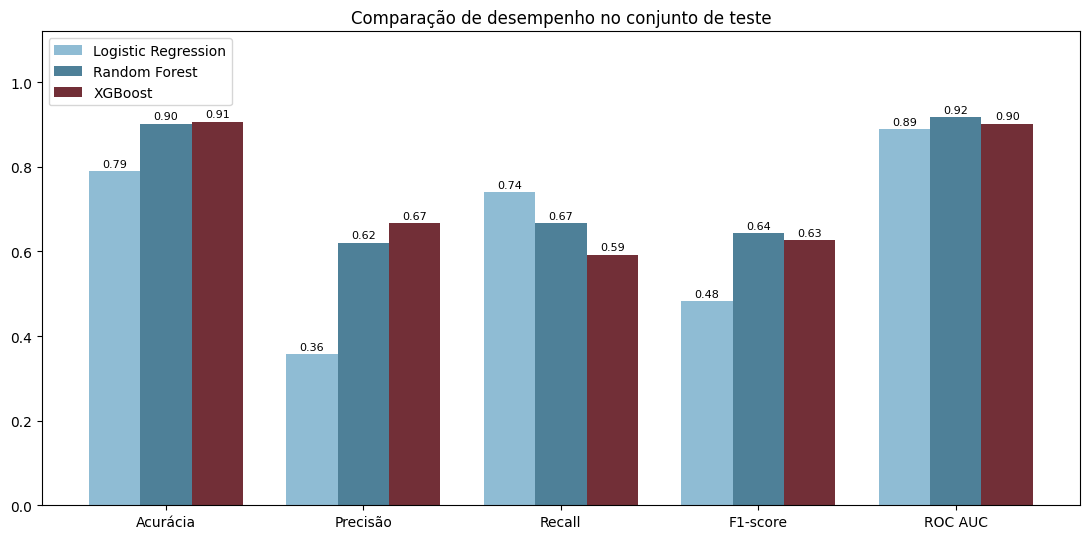

In [19]:
mets = ["Acurácia", "Precisão", "Recall", "F1-score", "ROC AUC"]
x = np.arange(len(mets))
w = 0.26
cores = ["#8FBCD4", "#4E8098", "#722F37"]
plt.figure(figsize=(11, 5.5))
for i, (nome, r) in enumerate(resultados.items()):
    vals = [r[m] for m in mets]
    plt.bar(x + (i - 1) * w, vals, w, label=nome, color=cores[i])
    for xi, v in zip(x + (i - 1) * w, vals):
        plt.text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
plt.xticks(x, mets)
plt.ylim(0, 1.12)
plt.legend()
plt.title("Comparação de desempenho no conjunto de teste")
plt.tight_layout()
plt.savefig(f"{RESULTS}/08_comparacao_modelos.png", bbox_inches="tight")
plt.show()

**Interpretação.** Os dois ensembles superam com folga o baseline linear em precisão e F1, evidência de que a relação entre físico-química e qualidade é **não linear e com interações**. A Regressão Logística atinge recall alto (≈ 0,74), mas ao custo de precisão baixa (≈ 0,36): "aposta" demais na classe premium. Random Forest e XGBoost são muito próximos; a distinção fina vem das curvas e da matriz de confusão a seguir.

### 6.3 Curvas ROC

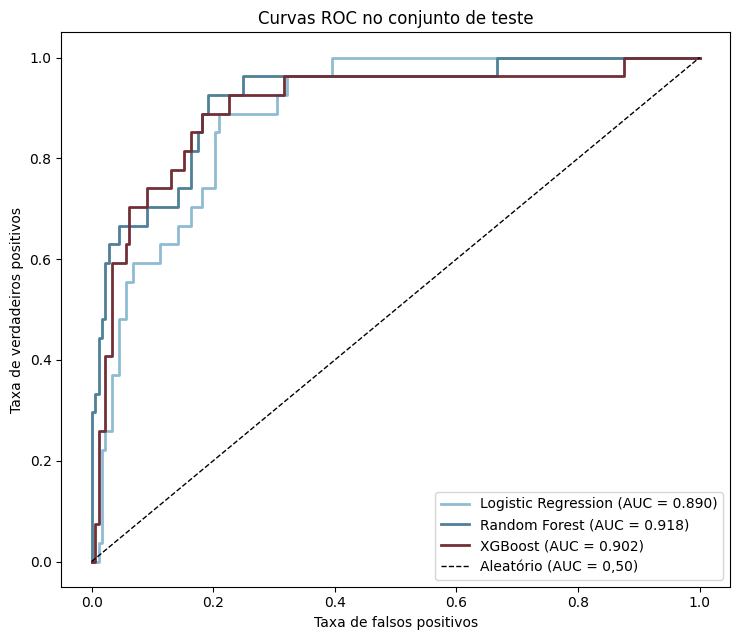

In [20]:
plt.figure(figsize=(7.5, 6.5))
for i, (nome, modelo) in enumerate(ajustados.items()):
    prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, color=cores[i], lw=2,
             label=f"{nome} (AUC = {resultados[nome]['ROC AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Aleatório (AUC = 0,50)")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curvas ROC no conjunto de teste")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{RESULTS}/09_curvas_roc.png", bbox_inches="tight")
plt.show()

**Interpretação.** Todos os modelos ficam muito acima da diagonal aleatória, com o **Random Forest liderando (AUC = 0,918)**: em cerca de 92% dos pares (premium, comum) o modelo atribui score maior ao vinho premium. A curva do RF domina as demais em quase toda a faixa de operação, portanto a liderança não é artefato de um único limiar.

### 6.4 Curva Precision-Recall

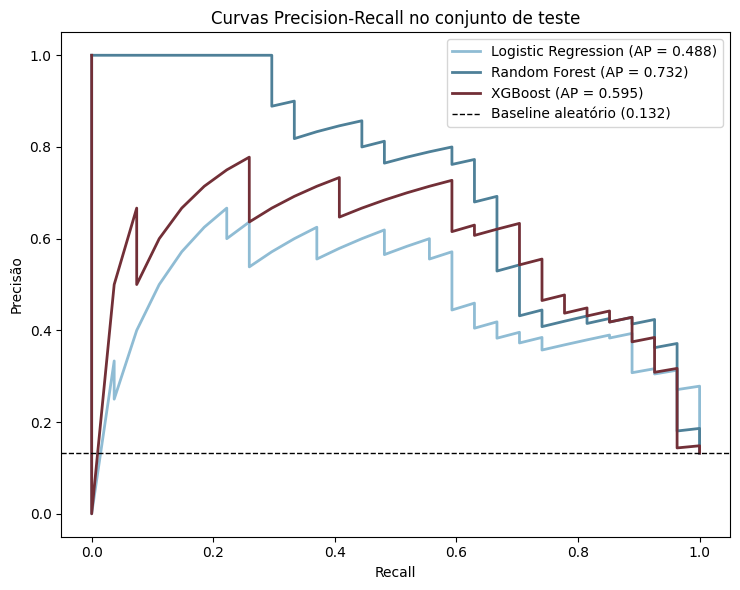

In [21]:
plt.figure(figsize=(7.5, 6))
for i, (nome, modelo) in enumerate(ajustados.items()):
    prob = modelo.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    plt.plot(rec, prec, color=cores[i], lw=2,
             label=f"{nome} (AP = {resultados[nome]['Avg Precision']:.3f})")
plt.axhline(y_test.mean(), color="k", ls="--", lw=1,
            label=f"Baseline aleatório ({y_test.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.title("Curvas Precision-Recall no conjunto de teste")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{RESULTS}/11_curva_precision_recall.png", bbox_inches="tight")
plt.show()

**Interpretação.** Sob desbalanceamento, esta é a curva decisiva. O baseline aleatório é a prevalência (0,13); o **Random Forest sustenta AP de 0,73** (mais de cinco vezes o aleatório) e mantém precisão alta até recalls próximos de 0,6. Na prática, a vinícola pode escolher o ponto de operação: um limiar mais alto para rotulagem premium (prioriza precisão) ou mais baixo para triagem de lotes a degustar (prioriza recall).

### 6.5 Matriz de confusão do modelo campeão

Modelo campeão: Random Forest


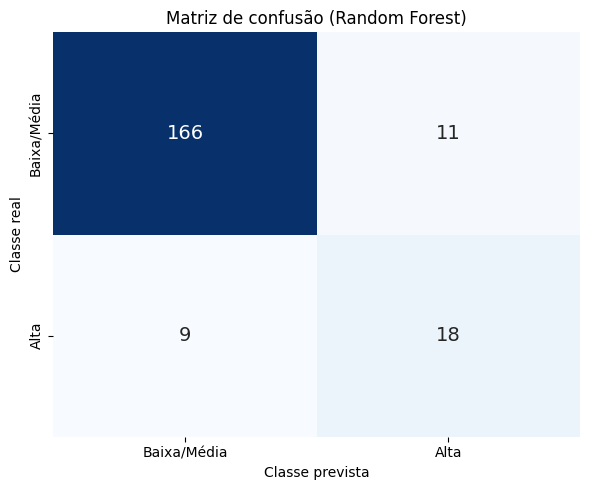

In [22]:
melhor_nome = max(resultados, key=lambda k: (resultados[k]["F1-score"],
                                             resultados[k]["ROC AUC"]))
melhor = ajustados[melhor_nome]
cm = confusion_matrix(y_test, melhor.predict(X_test))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Baixa/Média", "Alta"],
            yticklabels=["Baixa/Média", "Alta"], annot_kws={"size": 14})
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title(f"Matriz de confusão ({melhor_nome})")
plt.tight_layout()
plt.savefig(f"{RESULTS}/10_matriz_confusao.png", bbox_inches="tight")
plt.show()
print(f"Modelo campeão: {melhor_nome}")

**Interpretação (204 amostras de teste).** O Random Forest:

- identifica **18 dos 27 vinhos premium** (recall ≈ 67%);
- dos 29 vinhos que apontou como premium, **18 realmente são** (precisão ≈ 62%);
- comete apenas **11 falsos positivos** entre 177 vinhos comuns (≈ 6%).

**Por que o Random Forest foi escolhido.** Em validação cruzada os três modelos ficam tecnicamente empatados (F1 entre 0,520 e 0,525), de modo que o tuning sozinho não decide a escolha. No conjunto de teste, o Random Forest apresenta o melhor resultado nas três métricas mais relevantes para classe desbalanceada: F1 (0,643), ROC AUC (0,918) e Average Precision (0,732, contra 0,595 do XGBoost), além de recall superior (0,67 contra 0,59) justamente na tarefa que importa, localizar os lotes premium. A Regressão Logística permanece como baseline interpretável. A seção seguinte quantifica a incerteza estatística dessa comparação, como manda o rigor: o conjunto de teste tem apenas 27 positivos.

### 6.6 Robustez estatística da comparação

In [23]:
pred_rf = ajustados["Random Forest"].predict(X_test)
pred_xgb = ajustados["XGBoost"].predict(X_test)

# Teste de McNemar (binomial exato) sobre os acertos discordantes
so_rf = int(((pred_rf == y_test) & (pred_xgb != y_test)).sum())
so_xgb = int(((pred_rf != y_test) & (pred_xgb == y_test)).sum())
p_mcnemar = binomtest(so_rf, so_rf + so_xgb, 0.5).pvalue
print(f"McNemar RF x XGBoost: RF acerta sozinho {so_rf} casos, "
      f"XGBoost {so_xgb}; p-valor = {p_mcnemar:.3f}")

# Intervalo de confiança bootstrap (2.000 reamostragens) do F1 do RF
rng = np.random.default_rng(SEED)
y_arr = y_test.to_numpy()
f1_boot = []
for _ in range(2000):
    idx = rng.integers(0, len(y_arr), len(y_arr))
    if y_arr[idx].sum() == 0:
        continue
    f1_boot.append(f1_score(y_arr[idx], pred_rf[idx]))
ic_inf, ic_sup = np.percentile(f1_boot, [2.5, 97.5])
print(f"F1 do Random Forest: {f1_score(y_test, pred_rf):.3f} "
      f"| IC 95% bootstrap: [{ic_inf:.3f}, {ic_sup:.3f}]")

McNemar RF x XGBoost: RF acerta sozinho 5 casos, XGBoost 6; p-valor = 1.000
F1 do Random Forest: 0.643 | IC 95% bootstrap: [0.475, 0.778]


**Interpretação.** Com apenas 27 vinhos premium no teste, é obrigatório perguntar se a vantagem do Random Forest sobre o XGBoost é real ou ruído amostral. O teste de McNemar responde: p = 1,0, ou seja, **não há diferença estatisticamente significativa** entre os dois ensembles neste conjunto de teste. O intervalo de confiança bootstrap do F1 ([0,48; 0,78]) reforça a incerteza natural de uma classe rara.

A escolha do Random Forest é, portanto, uma decisão por critérios múltiplos (consistência em todas as métricas, Average Precision bem superior e maior recall na classe de interesse), e não uma alegação de superioridade estatística. Com mais dados de vinhos premium, a comparação deve ser refeita; explicitar esse limite faz parte do rigor do projeto.

<a id="7"></a>
## 7. Interpretação dos Resultados

### 7.1 Importância das variáveis

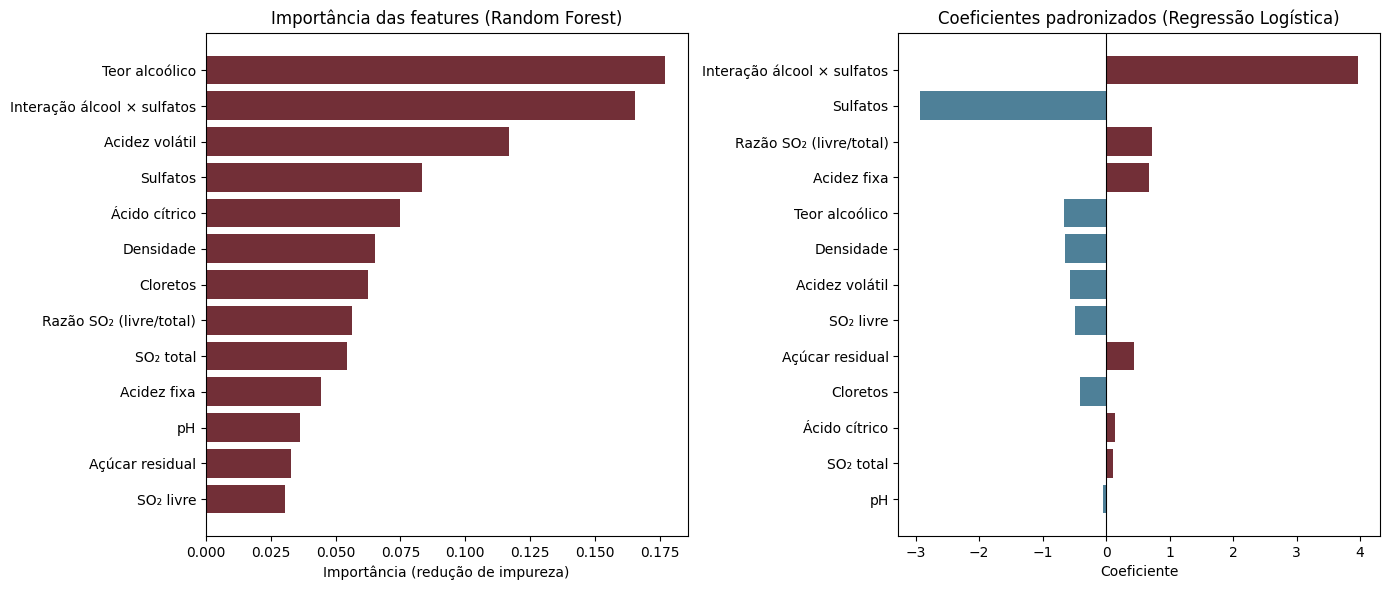

,Importância RF
alcohol,0.1768
interacao_alcool_sulfatos,0.1654
volatile acidity,0.1169
sulphates,0.0833
citric acid,0.0749
density,0.0651
chlorides,0.0626
razao_so2,0.0564
total sulfur dioxide,0.0545
fixed acidity,0.0445


In [24]:
rotulo = lambda c: LABELS_PT.get(c, c.replace("_", " ").capitalize())
feat_names = list(X_train.columns)

imp_rf = pd.Series(ajustados["Random Forest"].feature_importances_,
                   index=feat_names).sort_values()
coefs = pd.Series(ajustados["Logistic Regression"].named_steps["clf"].coef_[0],
                  index=feat_names)
coefs = coefs.reindex(coefs.abs().sort_values().index)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([rotulo(c) for c in imp_rf.index], imp_rf.values, color="#722F37")
axes[0].set_title("Importância das features (Random Forest)")
axes[0].set_xlabel("Importância (redução de impureza)")
cc = ["#722F37" if v > 0 else "#4E8098" for v in coefs.values]
axes[1].barh([rotulo(c) for c in coefs.index], coefs.values, color=cc)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("Coeficientes padronizados (Regressão Logística)")
axes[1].set_xlabel("Coeficiente")
plt.tight_layout()
plt.savefig(f"{RESULTS}/12_importancia_features.png", bbox_inches="tight")
plt.show()

imp_rf.sort_values(ascending=False).round(4).to_frame("Importância RF")

In [25]:
perm = permutation_importance(ajustados["Random Forest"], X_test, y_test,
                              scoring="f1", n_repeats=30,
                              random_state=SEED, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=feat_names)
imp_perm.sort_values(ascending=False).round(4).to_frame(
    "Importância por permutação (queda de F1 no teste)")

,Importância por permutação (queda de F1 no teste)
alcohol,0.2067
interacao_alcool_sulfatos,0.1953
citric acid,0.0889
volatile acidity,0.0770
sulphates,0.0620
density,0.0274
total sulfur dioxide,0.0238
razao_so2,0.0179
chlorides,0.0125
free sulfur dioxide,0.0012


**Interpretação.** O ranking do Random Forest é consistente com a EDA e com a literatura enológica:

1. **Teor alcoólico (17,7%)**: principal driver individual;
2. **Interação álcool × sulfatos (16,5%)**: a feature criada no projeto é a segunda mais importante, validando a hipótese de que corpo e proteção antioxidante atuam em conjunto;
3. **Acidez volátil (11,7%)**: o "detector de defeito";
4. **Sulfatos (8,3%)** e **ácido cítrico (7,5%)**: coadjuvantes positivos.

Como a importância por redução de impureza tende a favorecer variáveis contínuas, ela foi contrastada abaixo com a **importância por permutação**, que mede a queda real de F1 no conjunto de teste ao embaralhar cada variável. O topo se mantém: álcool (0,21) e interação álcool × sulfatos (0,20) dominam, seguidos por ácido cítrico, acidez volátil e sulfatos. A convergência entre os dois métodos dá segurança à leitura.

*Nota metodológica sobre os coeficientes da Regressão Logística:* com o termo de interação presente, os coeficientes individuais de álcool e sulfatos aparecem negativos por **multicolinearidade com a própria interação** (o efeito conjunto, +3,97, domina). É um lembrete clássico de que coeficientes individuais não devem ser lidos isoladamente quando há termos correlacionados; as importâncias do Random Forest, por impureza e por permutação, oferecem leitura mais estável.

### 7.2 Implicações para o processo de produção

1. **Maturação e fermentação** — priorizar colheitas e leveduras que elevem o teor alcoólico natural: é o fator com maior impacto na classificação premium.
2. **Controle rígido da acidez volátil** — monitoramento contínuo e higiene fermentativa para mantê-la abaixo de ≈ 0,5 g/L; é a alavanca de defeito mais sensível.
3. **Dosagem otimizada de sulfatos** — o efeito positivo é potencializado em vinhos de maior teor alcoólico (interação); ajustar a dose por perfil de lote, não por receita fixa.
4. **Triagem laboratorial automatizada** — com AUC ≈ 0,92, o modelo pode ranquear lotes pela probabilidade de qualidade premium e direcionar o painel sensorial apenas aos casos limítrofes, reduzindo custo e tempo de avaliação.

### 7.3 Limitações e melhorias futuras

- **Base modesta (1.018 amostras) e apenas 137 positivos** — ampliar a coleta, especialmente de vinhos premium, é a melhoria de maior retorno.
- **Ausência de variáveis de contexto** (safra, uva, região, barrica) que sabidamente afetam qualidade.
- **Técnicas de reamostragem** (SMOTE/undersampling) podem ser comparadas à ponderação de classes utilizada.
- **Interpretabilidade avançada**: valores SHAP dariam explicações por amostra (por que *este* lote foi classificado premium).
- **Calibração de probabilidade e ajuste de limiar** por custo de negócio (preço do falso premium vs. premium perdido).
- **Empilhamento (stacking)** dos três modelos e otimização bayesiana de hiperparâmetros.

<a id="8"></a>
## 8. Conclusões e Recomendações

**Conclusões técnicas**

- O problema foi formulado como classificação binária (nota ≥ 7), justificado pela decisão de negócio e pela escassez das classes extremas.
- A EDA identificou álcool (+) e acidez volátil (−) como os marcadores dominantes de qualidade, ambos com fundamento enológico.
- O pipeline tratou duplicatas (125 removidas), confirmou ausência de faltantes, manteve outliers legítimos e validou feature engineering com ganho mensurável em CV.
- Entre três modelos comparados sob protocolo idêntico, o **Random Forest** foi selecionado: **acurácia 90,2%, precisão 62,1%, recall 66,7%, F1 0,643 e ROC AUC 0,918** no conjunto de teste, com a incerteza da comparação explicitamente quantificada (teste de McNemar e IC bootstrap).

**Recomendação executiva**

O modelo está apto a operar como **ferramenta de triagem**: classifica automaticamente cada lote a partir de medições laboratoriais de rotina, encontra 2 de cada 3 vinhos premium e erra em apenas ≈ 6% dos vinhos comuns. O painel de especialistas passa a focar nos lotes de fronteira, com ganho direto de custo e velocidade; o processo produtivo, por sua vez, ganha alavancas objetivas (álcool, acidez volátil, sulfatos) para elevar a proporção de lotes premium.

---
*Notebook desenvolvido para o Tech Challenge Fase 2 (POSTECH DTAT). Reprodutível de ponta a ponta, com `random_state=42` em todas as etapas estocásticas.*